In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

DATA_PATH = "../data/crop_yield.csv"

df = pd.read_csv(DATA_PATH)
print(f"Total rows (all crops): {len(df)}")
print(f"Columns: {list(df.columns)}")

maize_df = df[df["Crop"] == "Maize"].reset_index(drop=True)
print(f"\nRows after filtering to Maize: {len(maize_df)}")
maize_df.head()

Total rows (all crops): 1000000
Columns: ['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition', 'Days_to_Harvest', 'Yield_tons_per_hectare']

Rows after filtering to Maize: 166824


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,South,Clay,Maize,888.207630,39.945509,True,False,Rainy,76,7.173037
1,East,Chalky,Maize,170.814456,29.116377,False,True,Sunny,133,2.332255
2,South,Silt,Maize,259.418125,17.261892,False,False,Sunny,110,2.338541
3,East,Silt,Maize,609.798764,38.265851,True,False,Cloudy,127,5.113588
4,East,Clay,Maize,599.875493,19.909292,True,False,Cloudy,63,4.696425


In [3]:
print("=== Data types ===")
print(maize_df.dtypes)

print("\n=== Missing values ===")
print(maize_df.isnull().sum())

print(f"\n=== Duplicate rows ===\n{maize_df.duplicated().sum()}")

print("\n=== Summary statistics ===")
print(maize_df.describe().to_string())

=== Data types ===
Region                        str
Soil_Type                     str
Crop                          str
Rainfall_mm               float64
Temperature_Celsius       float64
Fertilizer_Used              bool
Irrigation_Used              bool
Weather_Condition             str
Days_to_Harvest             int64
Yield_tons_per_hectare    float64
dtype: object

=== Missing values ===
Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

=== Duplicate rows ===
0

=== Summary statistics ===
         Rainfall_mm  Temperature_Celsius  Days_to_Harvest  Yield_tons_per_hectare
count  166824.000000        166824.000000    166824.000000           166824.000000
mean      549.195094            27.477555       104.538927                4.641387
std    

In [4]:
categorical_cols = ["Region", "Soil_Type", "Fertilizer_Used", "Irrigation_Used", "Weather_Condition"]

for col in categorical_cols:
    print(f"=== {col} ===")
    print(maize_df[col].value_counts())
    print()

=== Region ===
Region
North    41830
West     41739
South    41725
East     41530
Name: count, dtype: int64

=== Soil_Type ===
Soil_Type
Loam      27908
Chalky    27885
Peaty     27819
Silt      27793
Sandy     27788
Clay      27631
Name: count, dtype: int64

=== Fertilizer_Used ===
Fertilizer_Used
False    83670
True     83154
Name: count, dtype: int64

=== Irrigation_Used ===
Irrigation_Used
False    83419
True     83405
Name: count, dtype: int64

=== Weather_Condition ===
Weather_Condition
Sunny     55838
Rainy     55663
Cloudy    55323
Name: count, dtype: int64



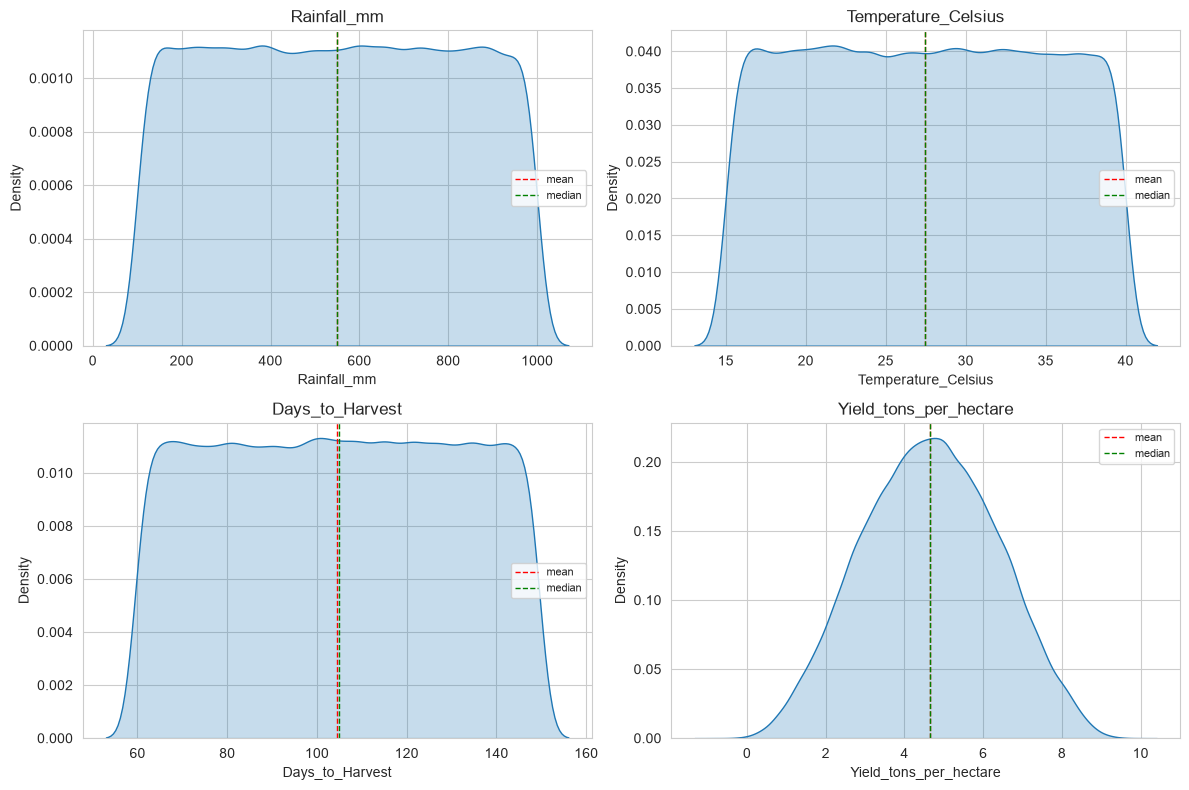

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
numeric_cols = ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest", "Yield_tons_per_hectare"]
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.kdeplot(maize_df[col], fill=True, ax=ax)
    ax.axvline(maize_df[col].mean(), color="red", linestyle="--", linewidth=1, label="mean")
    ax.axvline(maize_df[col].median(), color="green", linestyle="--", linewidth=1, label="median")
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

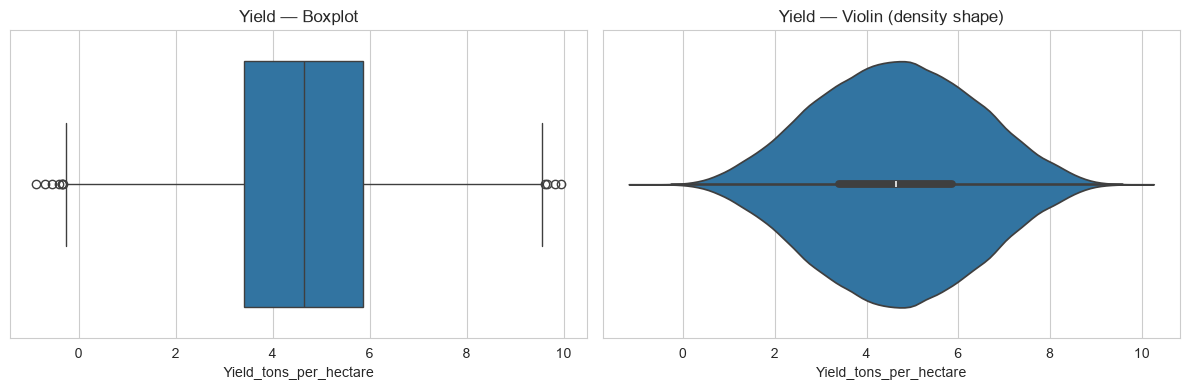

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=maize_df["Yield_tons_per_hectare"], ax=ax[0])
ax[0].set_title("Yield — Boxplot")
sns.violinplot(x=maize_df["Yield_tons_per_hectare"], ax=ax[1])
ax[1].set_title("Yield — Violin (density shape)")
plt.tight_layout()
plt.show()

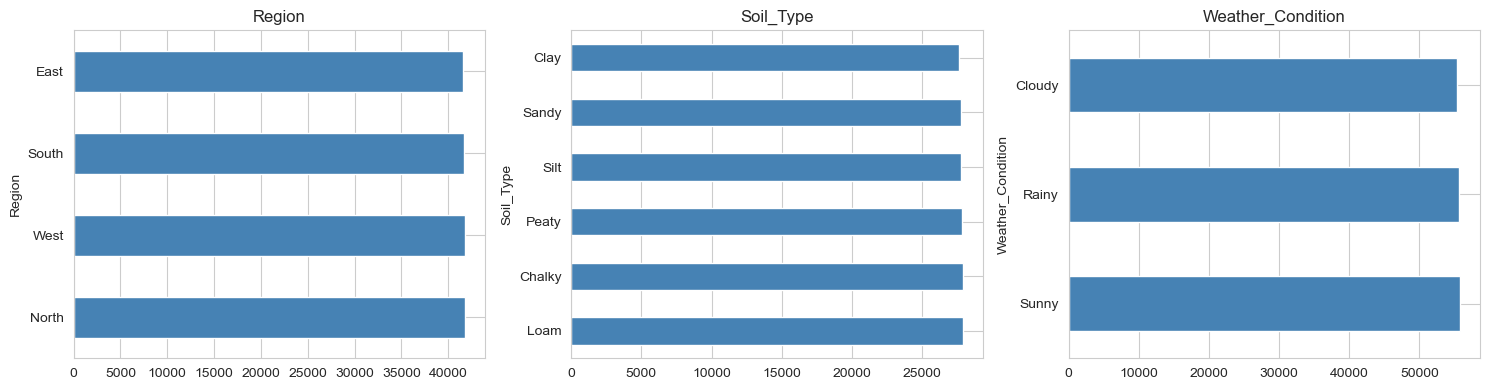

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Region", "Soil_Type", "Weather_Condition"]):
    maize_df[col].value_counts().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

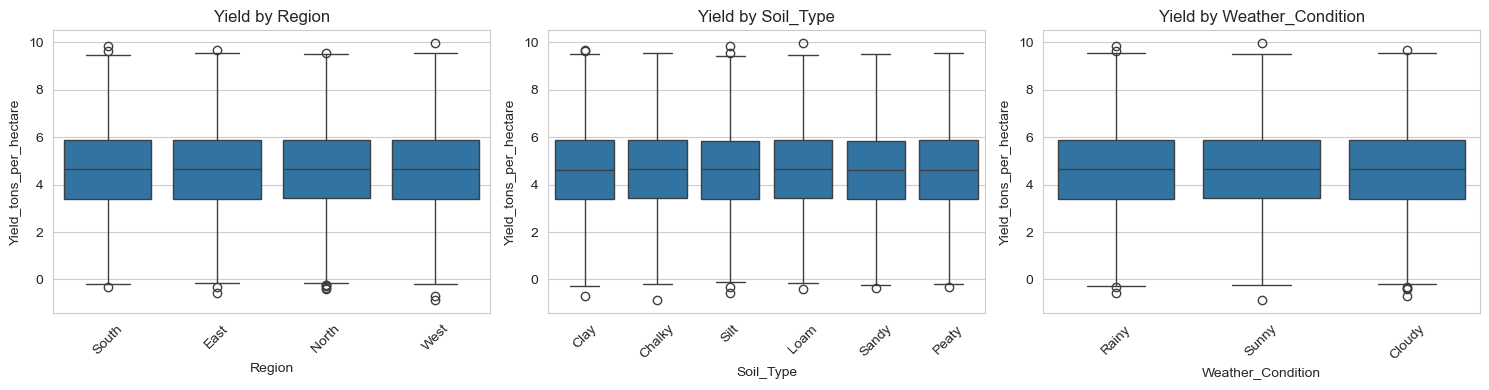

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Region", "Soil_Type", "Weather_Condition"]):
    sns.boxplot(data=maize_df, x=col, y="Yield_tons_per_hectare", ax=ax)
    ax.set_title(f"Yield by {col}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

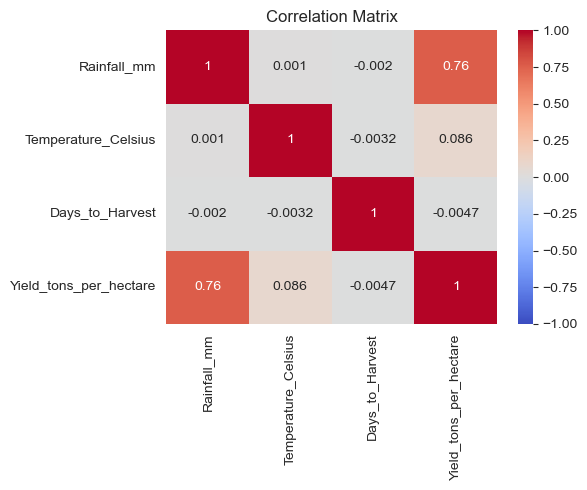

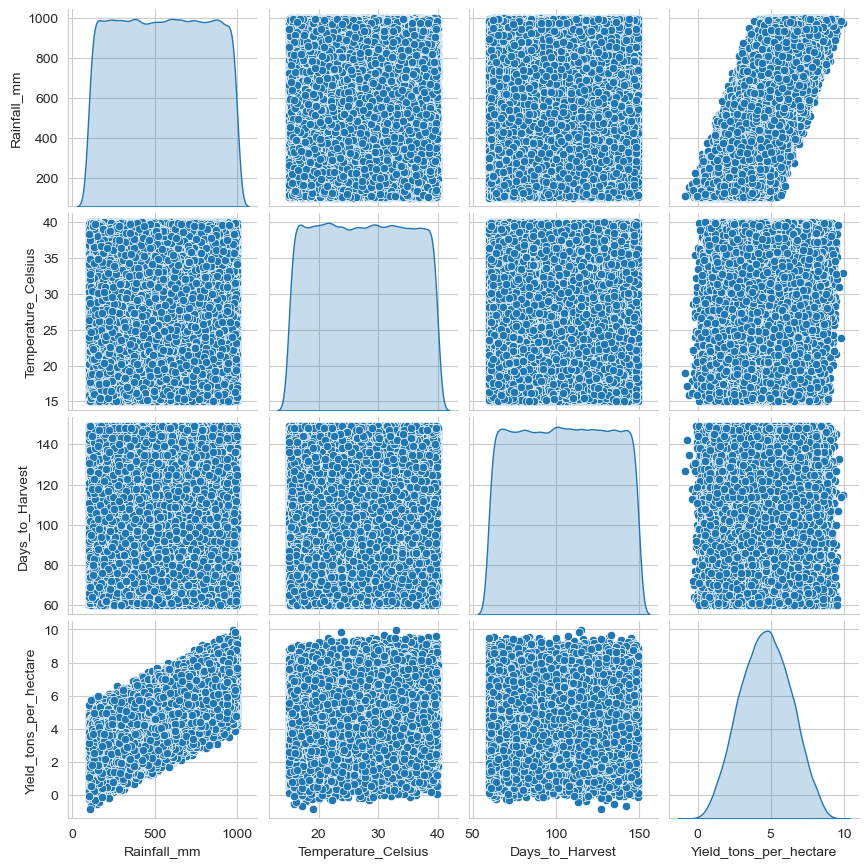

In [9]:
corr_cols = ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest", "Yield_tons_per_hectare"]
plt.figure(figsize=(6, 5))
sns.heatmap(maize_df[corr_cols].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

sns.pairplot(maize_df[corr_cols], diag_kind="kde", height=2.2)
plt.show()